## Georg Seismic Experiment

Explore seismic signals at Bonn

## Imports

In [1]:
import os
import gc
import matplotlib.pyplot as plt
import numpy as np
import obspy as obs
import pandas as pd

from obspy.signal import PPSD

from andbro__read_sds import __read_sds
from andbro__trim_stream import __trim_stream

## Configurations

In [4]:
config = {}

config['workdir'] = "/home/andbro/"
config['workdir'] = "/import/"

config['path_to_inv'] = config['workdir']+"kilauea-data/GEORG/stationxml/"

config['path_to_data'] = config['workdir']+"kilauea-data/GEORG/data/"

config['path_to_figs'] = config['workdir']+"kilauea-data/GEORG/figs/"

config['tbeg'] = obs.UTCDateTime("2024-12-17 02:00")
config['tend'] = obs.UTCDateTime("2024-12-17 04:00")

# config['tbeg'] = obs.UTCDateTime("2024-12-17 05:00")
# config['tend'] = obs.UTCDateTime("2024-12-17 06:00")


### Load Data

### Load Seismometer Data

In [5]:
# st_seis = obs.read(config['path_to_data']+'BONN_centaur-3_10343_20241216_180000.seed')
st_seis = __read_sds(config['path_to_data'], "XN.BONN..HH*", config['tbeg'], config['tend'])

inv_seis = obs.read_inventory(config['path_to_inv']+'station_XX_BONN.xml')

st_seis.remove_response(inv_seis, output="ACC")

print(st_seis)

3 Trace(s) in Stream:
XN.BONN..HHE | 2024-12-17T02:00:00.000000Z - 2024-12-17T04:00:00.000000Z | 200.0 Hz, 1440001 samples
XN.BONN..HHN | 2024-12-17T02:00:00.000000Z - 2024-12-17T04:00:00.000000Z | 200.0 Hz, 1440001 samples
XN.BONN..HHZ | 2024-12-17T02:00:00.000000Z - 2024-12-17T04:00:00.000000Z | 200.0 Hz, 1440001 samples

3 Trace(s) in Stream:
XN.BONN..HHE | 2024-12-17T02:00:00.000000Z - 2024-12-17T04:00:00.000000Z | 200.0 Hz, 1440001 samples
XN.BONN..HHN | 2024-12-17T02:00:00.000000Z - 2024-12-17T04:00:00.000000Z | 200.0 Hz, 1440001 samples
XN.BONN..HHZ | 2024-12-17T02:00:00.000000Z - 2024-12-17T04:00:00.000000Z | 200.0 Hz, 1440001 samples


### Load Tiltmeter Data

In [6]:
st_tilt = __read_sds(config['path_to_data'], "XX.TILT..LA*", config['tbeg'], config['tend'])

print(st_tilt)

2 Trace(s) in Stream:
XX.TILT..LAE | 2024-12-17T02:00:00.263273Z - 2024-12-17T03:59:59.848575Z | 0.9 Hz, 6825 samples
XX.TILT..LAN | 2024-12-17T02:00:00.263273Z - 2024-12-17T03:59:59.848575Z | 0.9 Hz, 6825 samples


In [7]:
for tr in st_tilt:
    tr.data *= 9.81

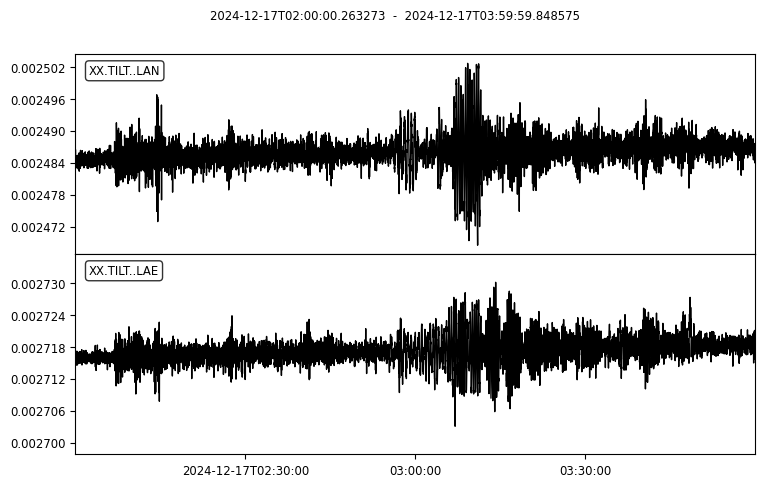

In [8]:
st_tilt.plot();

### Load RaspShake Data

In [9]:
st_rasp = __read_sds(config['path_to_data'], "AM.RACB0.00.EH*", config['tbeg'], config['tend'])

inv_rasp = obs.read_inventory(config['path_to_inv']+"station_AM_RACB0.xml")

st_rasp = st_rasp.remove_response(inv_rasp, output="ACC")


In [10]:
st_rasp

2 Trace(s) in Stream:
AM.RACB0.00.EHE | 2024-12-17T01:59:59.997000Z - 2024-12-17T03:59:59.997000Z | 100.0 Hz, 720001 samples
AM.RACB0.00.EHZ | 2024-12-17T01:59:59.997000Z - 2024-12-17T03:59:59.997000Z | 100.0 Hz, 720001 samples

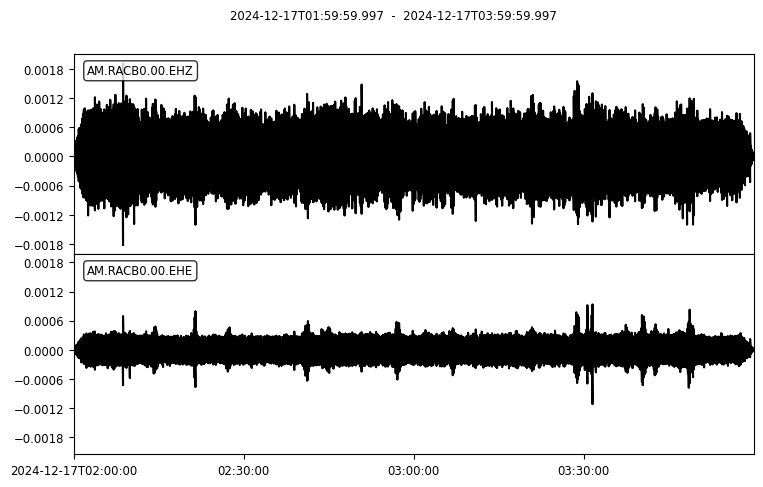

In [11]:
st_rasp.plot();

### Combine Data

In [12]:
st0 = obs.Stream()
st0 += st_seis.copy()
st0 += st_tilt.copy()
st0 += st_rasp.copy()

In [13]:
st = st0.copy()

st = st.detrend("demean")
st = st.taper(0.05)
st = st.filter("bandpass", freqmin=0.01, freqmax=0.1, corners=4, zerophase=True)

st = st.trim(config['tbeg'], config['tend'])

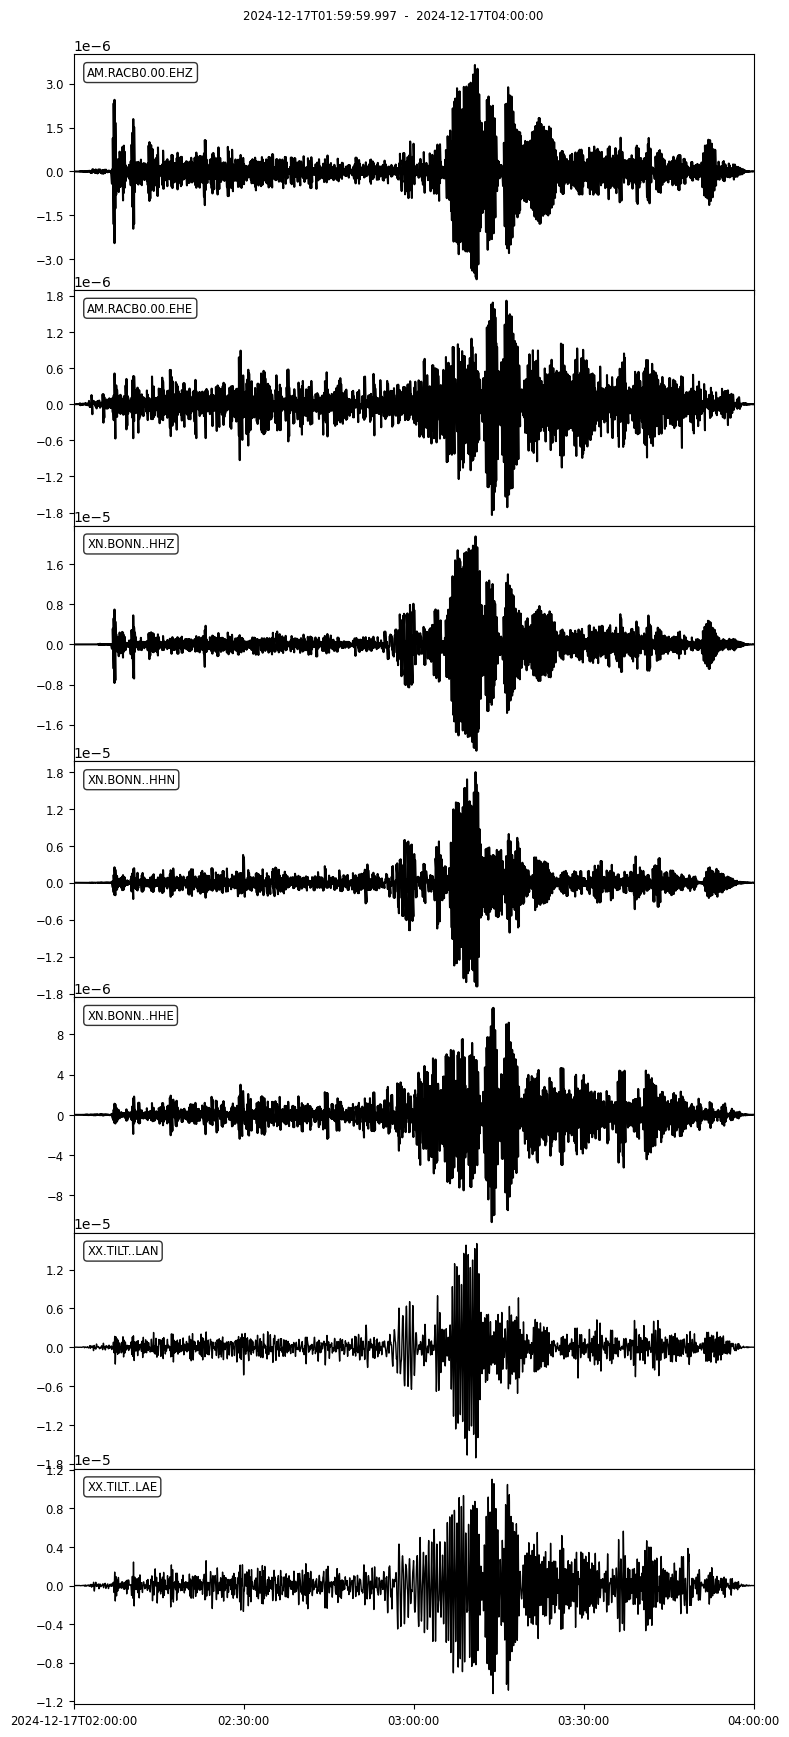

In [14]:
st.plot(equal_scale=False);

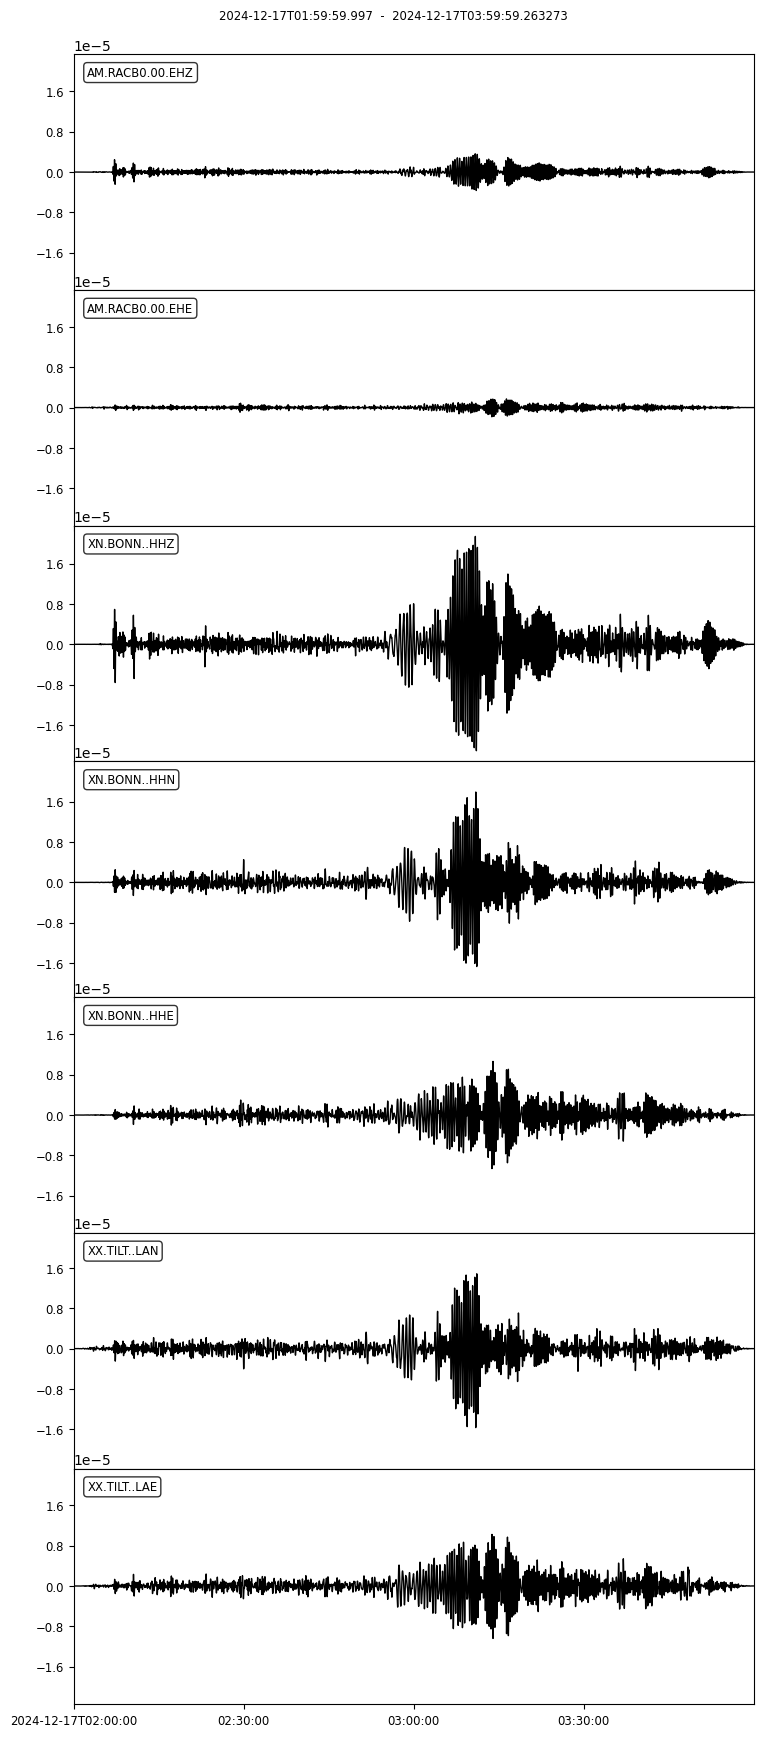

In [15]:
stx = st.copy()

# stx = stx.trim(config['tbeg']+3100, config['tend']-2200)

stx = stx.resample(1)

stx = __trim_stream(stx, set_common=True, set_interpolate=True)

stx.plot();

In [16]:
from andbro__crosscorrelationTraces import __crosscorrelationTraces

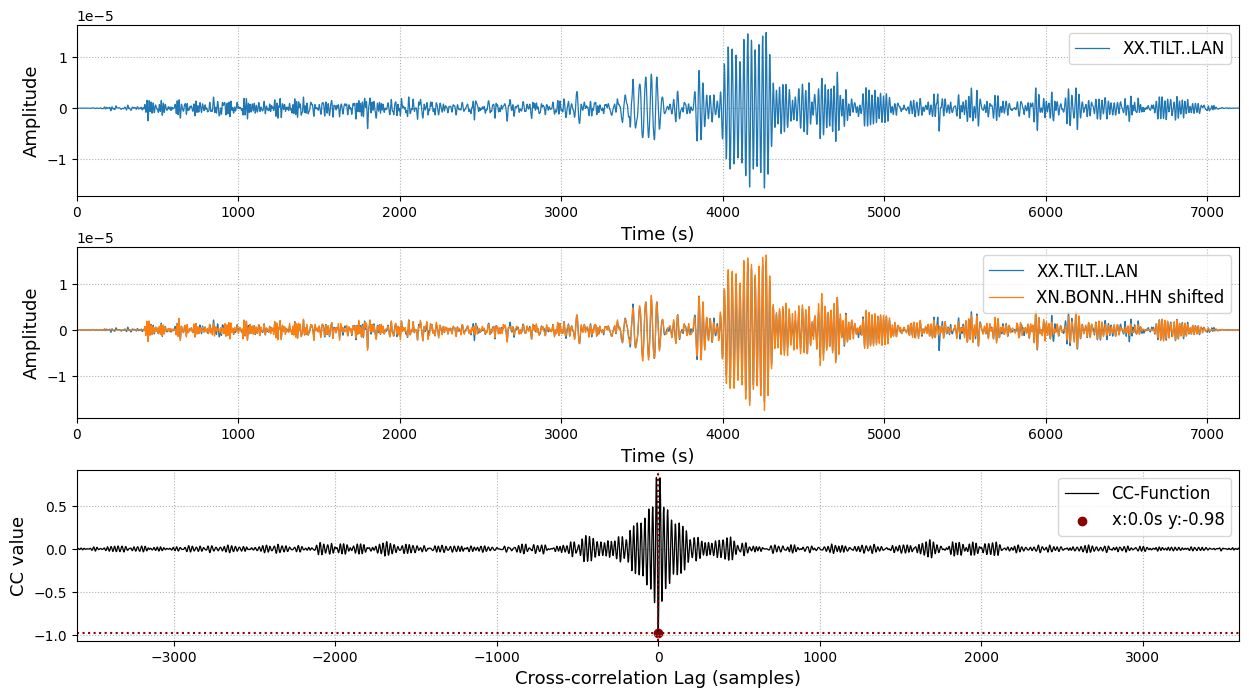

Maximum Correlation: 
 x: 0s 
 y: -0.98


In [29]:
tr1 = stx.select(channel="LAN")[0]
tr2 = stx.select(channel="HHN")[0]

out = __crosscorrelationTraces(tr1, tr2)

# out['figure'].savefig(config['path_to_figs']+"CC_n.png", format="png", dpi=150, bbox_inches='tight')


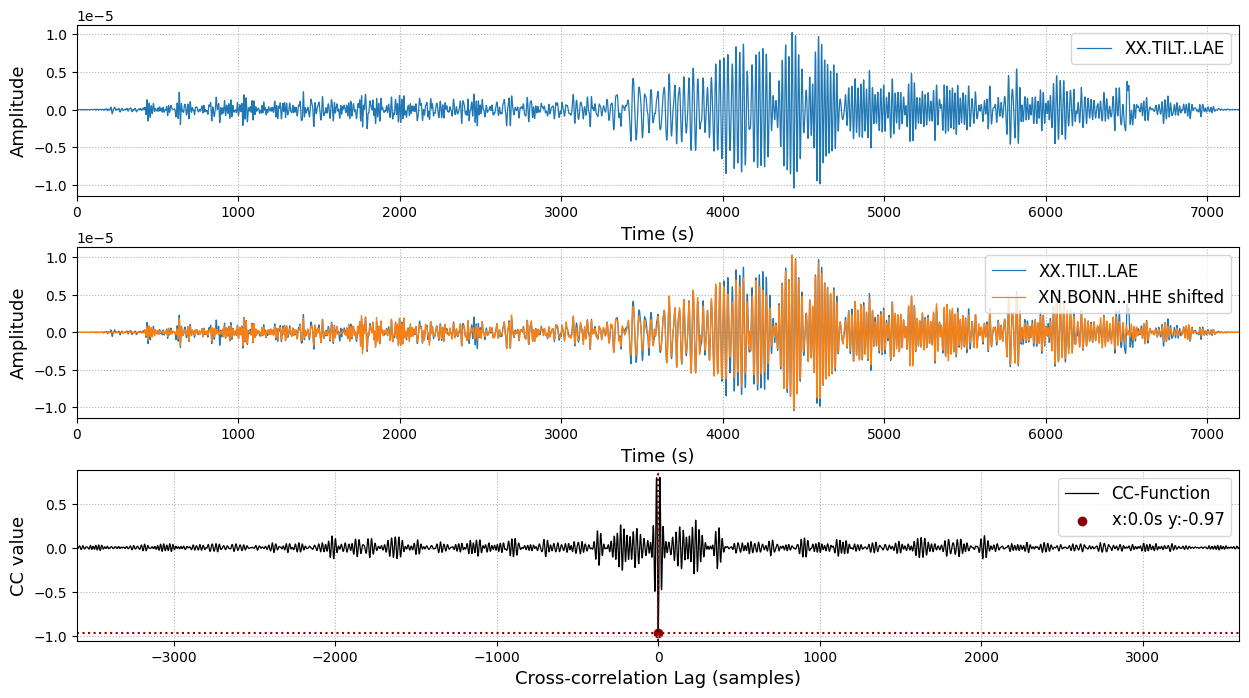

Maximum Correlation: 
 x: 0s 
 y: -0.97


In [28]:
tr1 = stx.select(channel="LAE")[0]
tr2 = stx.select(channel="HHE")[0]

out = __crosscorrelationTraces(tr1, tr2)

# out['figure'].savefig(config['path_to_figs']+"CC_e.png", format="png", dpi=150, bbox_inches='tight')


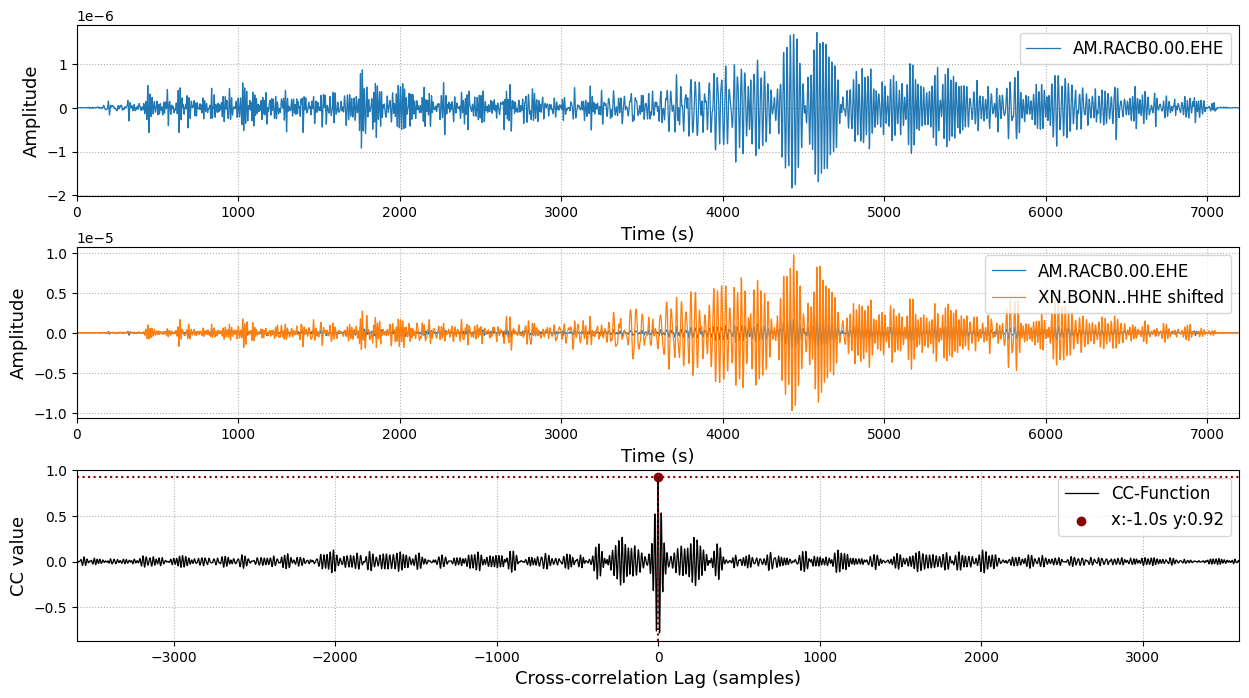

Maximum Correlation: 
 x: -1s 
 y: 0.92


dict_keys(['ccorr', 'xlags', 'maximum', 'figure'])

In [26]:
tr1 = stx.select(channel="EHE")[0]
tr2 = stx.select(channel="HHE")[0]

out = __crosscorrelationTraces(tr1, tr2)

# out['figure'].savefig(config['path_to_figs']+"CC_e_rasp.png", format="png", dpi=150, bbox_inches='tight')


In [18]:
def __compare_psd_stream(st0, twin_sec=3600, psd="welch", time_bandwidth=None, n_win=5, plot=True):

    def __welch_psd(arr, dt, twin_sec=60):

        from scipy.signal import welch
        from scipy.signal.windows import hann

        nblock = int(1/dt * twin_sec)
        overlap = int(0.5*nblock)
        win = hann(nblock, True)

        ff, Pxx = welch(arr,
                        fs=1/dt,
                        window=win,
                        noverlap=overlap,
                        nfft=nblock,
                        scaling="density",
                        return_onesided=True)

        return ff, Pxx

    def __multitaper_psd(arr, dt, n_win=5, time_bandwidth=4.0):

        import multitaper as mt

        out_psd = mt.MTSpec(arr, nw=time_bandwidth, kspec=n_win, dt=dt, iadapt=2)

        _f, _psd = out_psd.rspec()

        f = _f.reshape(_f.size)
        psd = _psd.reshape(_psd.size)

        ## 95% confidence interval
        # _psd95 = out_psd.jackspec()
        # psd95_lower, psd95_upper = psd95[::2, 0], psd95[::2, 1]

        return f, psd

    fxxs, pxxs = {}, {}

    for tr in st0:

        seed = tr.get_id()

        if psd == "welch":
            fxxs[seed], pxxs[seed] = __welch_psd(tr.data, tr.stats.delta, twin_sec)
        elif psd == "multitaper":
            fxxs[seed], pxxs[seed] = __multitaper_psd(tr.data, tr.stats.delta, n_win=n_win, time_bandwidth=time_bandwidth)

    if plot:

        Nrow, Ncol = 1, 1

        font = 12

        fig, ax = plt.subplots(Nrow, Ncol, figsize=(15, 8))

        for tr in st0:

            ax.plot(fxxs[tr.get_id()], pxxs[tr.get_id()], label=tr.get_id())

        ax.set_xscale("log")
        ax.set_yscale("log")

        ax.grid(ls=":", zorder=0)
        ax.legend(loc=1)

        ax.set_xlim(1/twin_sec, 0.5/tr.stats.delta)

        ax.set_xlabel("Frequency (Hz")
        ax.set_ylabel("PSD")

        plt.show();

    return fxxs, pxxs

In [19]:
st2 = st0.copy()

st2 = st2.detrend("demean")

st2 = st2.taper(0.01)

# st2 = st2.resample(1.0, no_filter=False)

fxx, pxx = __compare_psd_stream(st2, twin_sec=1800, psd="welch", plot=False)

# fxx, pxx = __compare_psd_stream(st2, n_win=10, time_bandwidth=3.5, psd="multitaper", plot=False)


In [22]:
models = np.load(config['workdir']+"kilauea-data/GEORG/data/"+"noise_models.npz")

In [23]:
models

NpzFile '/import/kilauea-data/GEORG/data/noise_models.npz' with keys: low_noise, model_periods, high_noise

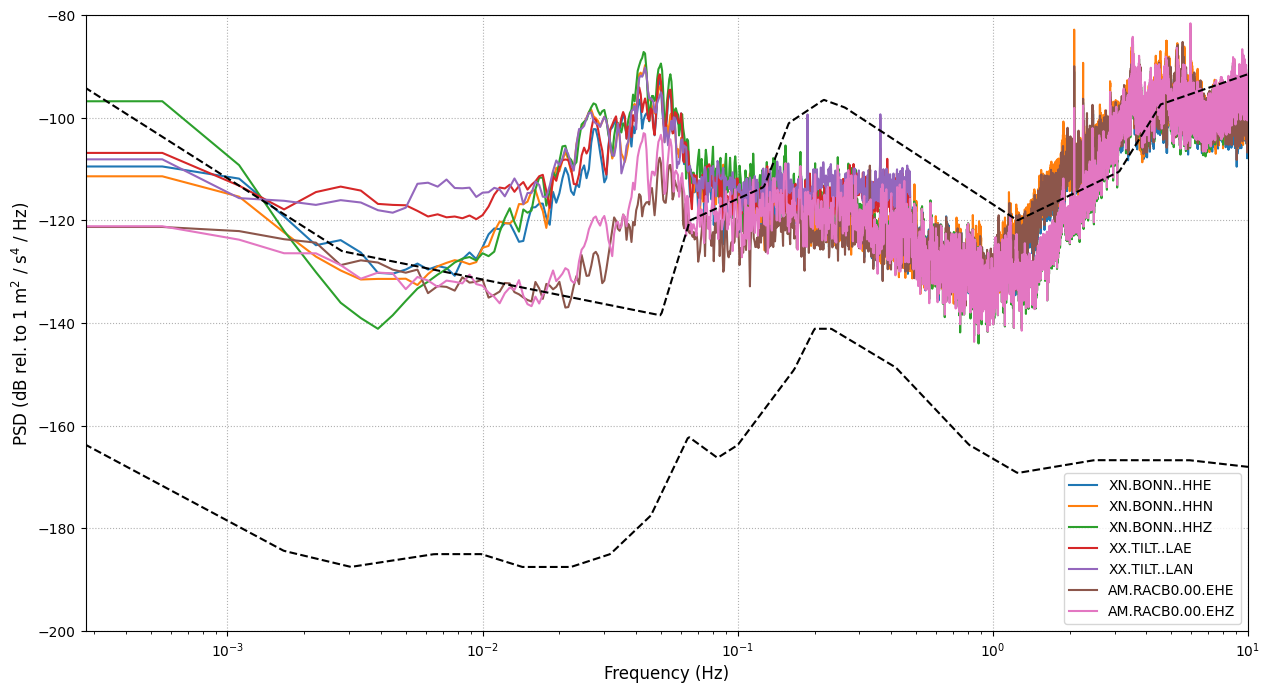

In [24]:
Nrow, Ncol = 1, 1

font = 12

fig, ax = plt.subplots(Nrow, Ncol, figsize=(15, 8))

for tr in st2:

    ax.plot(fxx[tr.get_id()], 10*np.log10(pxx[tr.get_id()]), label=tr.get_id())

ax.plot(1/models['model_periods'], models['low_noise'], color="k", ls="--")
ax.plot(1/models['model_periods'], models['high_noise'], color="k", ls="--")

ax.set_xscale("log")
# ax.set_yscale("log")

ax.set_ylim(-200, -80)

ax.grid(ls=":", zorder=0)
ax.legend(loc=4)

fmax = 0.5/tr.stats.delta

if fmax < 10:
    ax.set_xlim(1/3600, fmax)
else:
    ax.set_xlim(1/3600, 10)

ax.set_xlabel(r"Frequency (Hz)", fontsize=font)
ax.set_ylabel(r"PSD (dB rel. to 1 m$^2$ / s$^4$ / Hz)", fontsize=font)

plt.show();

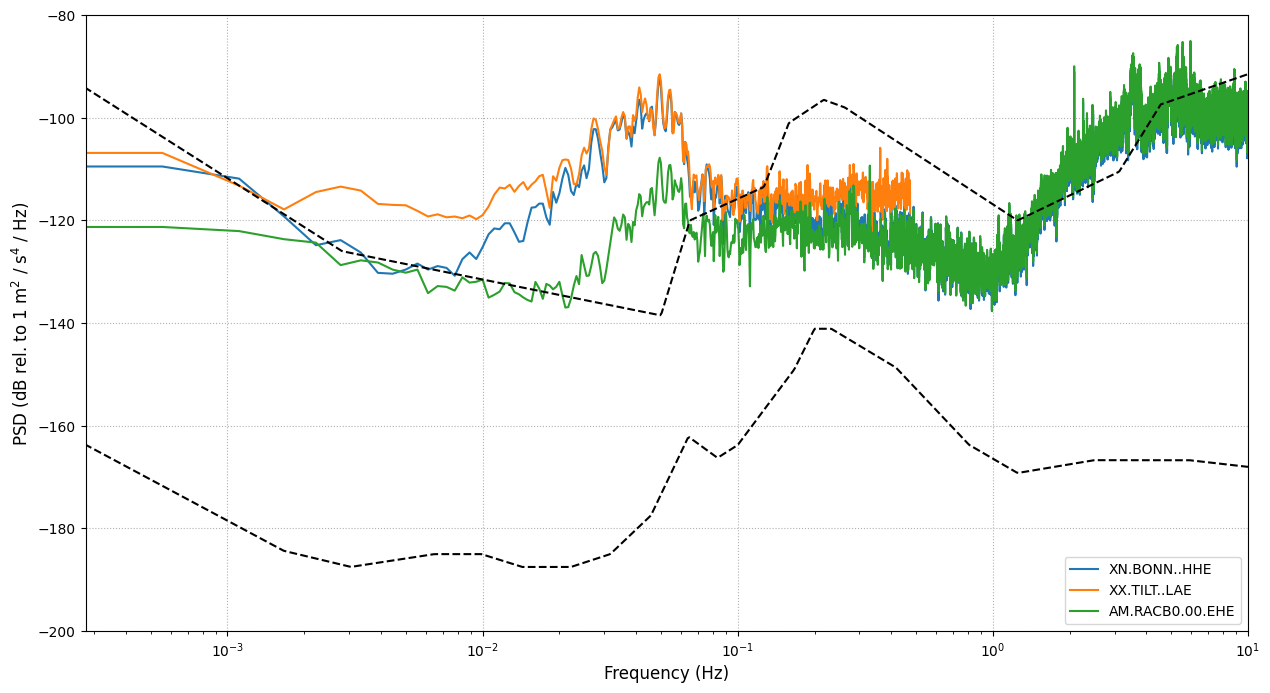

In [31]:
Nrow, Ncol = 1, 1

font = 12

fig, ax = plt.subplots(Nrow, Ncol, figsize=(15, 8))

for tr in st2.select(channel="*E"):

    ax.plot(fxx[tr.get_id()], 10*np.log10(pxx[tr.get_id()]), label=tr.get_id())

ax.plot(1/models['model_periods'], models['low_noise'], color="k", ls="--")
ax.plot(1/models['model_periods'], models['high_noise'], color="k", ls="--")

ax.set_xscale("log")
# ax.set_yscale("log")

ax.set_ylim(-200, -80)

ax.grid(ls=":", zorder=0)
ax.legend(loc=4)

fmax = 0.5/tr.stats.delta

if fmax < 10:
    ax.set_xlim(1/3600, fmax)
else:
    ax.set_xlim(1/3600, 10)

ax.set_xlabel(r"Frequency (Hz)", fontsize=font)
ax.set_ylabel(r"PSD (dB rel. to 1 m$^2$ / s$^4$ / Hz)", fontsize=font)

plt.show();

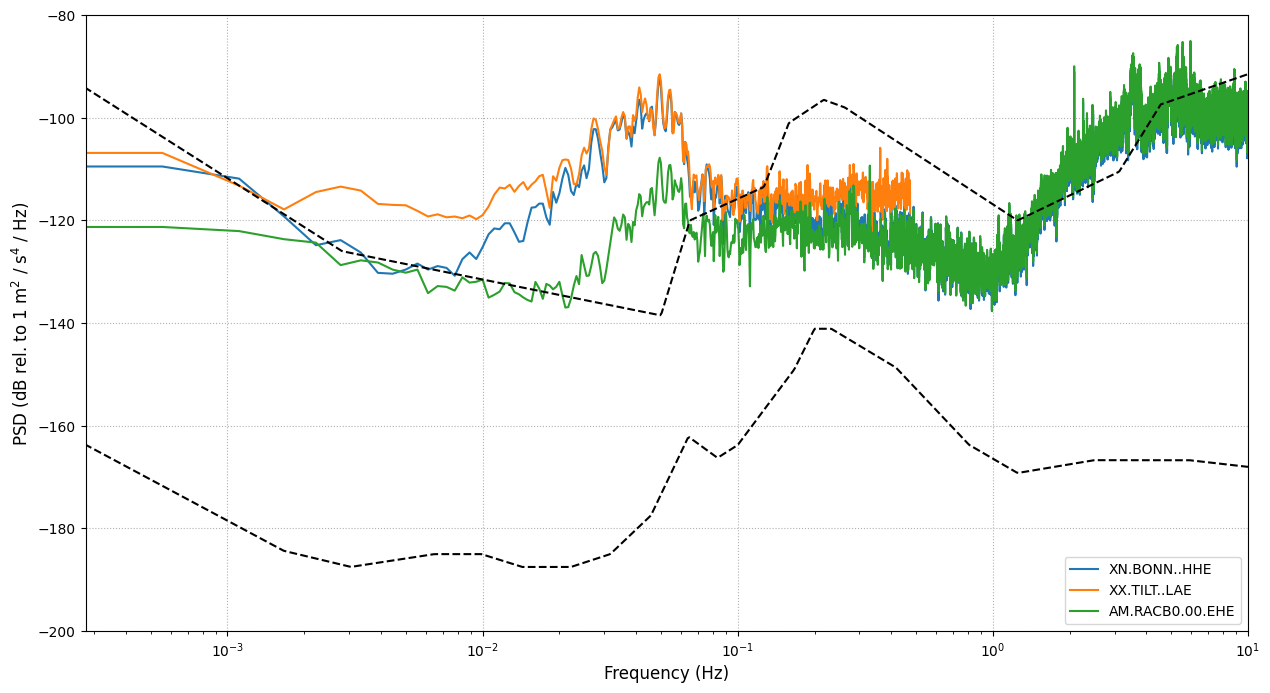

In [33]:
Nrow, Ncol = 1, 1

font = 12

fig, ax = plt.subplots(Nrow, Ncol, figsize=(15, 8))

for tr in st2.select(channel="*E"):

    ax.plot(fxx[tr.get_id()], 10*np.log10(pxx[tr.get_id()]), label=tr.get_id())

ax.plot(1/models['model_periods'], models['low_noise'], color="k", ls="--")
ax.plot(1/models['model_periods'], models['high_noise'], color="k", ls="--")

ax.set_xscale("log")
# ax.set_yscale("log")

ax.set_ylim(-200, -80)

ax.grid(ls=":", zorder=0)
ax.legend(loc=4)

fmax = 0.5/tr.stats.delta

if fmax < 10:
    ax.set_xlim(1/3600, fmax)
else:
    ax.set_xlim(1/3600, 10)

ax.set_xlabel(r"Frequency (Hz)", fontsize=font)
ax.set_ylabel(r"PSD (dB rel. to 1 m$^2$ / s$^4$ / Hz)", fontsize=font)

plt.show();

In [ ]:
%matplotlib tk

shift = stx.select(channel="EHN")[0].data
shift = np.roll(shift, -5)

plt.plot(stx.select(channel="HHN")[0].times(), stx.select(channel="HHN")[0].data/10)
# plt.plot(stx.select(channel="LAN")[0].times(), stx.select(channel="LAN")[0].data)
plt.plot(stx.select(channel="EHN")[0].times(), shift)
plt.show()

In [ ]:
config['set_filter'] = False
config['upper_corner_frequency'] = 0.1
config['lower_corner_frequency'] = None

__makeplotStreamSpectra(st, config)